# Pareto sweep analysis

Load a `summary.csv` or `summary.json` from a `pareto_runs/` directory and visualize the Pareto front.

**New sweeps** use seeded eval (`eval_seeds` in `summary.json`) and Pareto dominance on **`mean_acc`** (maximize) vs metabolic / wiring costs (minimize). Legacy runs still plot **`task_loss`**.

Run **eval seed calibration** (cells below) once to validate `DEFAULT_EVAL_SEEDS` in `pareto.py` (currently 10 seeds starting at 10000).

Interactive Plotly + matplotlib Pareto panels; λ-sweep row plots accuracy and costs vs λ.

## Eval seed calibration (run once)

Sweep how many fixed eval seeds are needed for stable **mean_acc** on easy tasks (`easy_task=True`, noiseless). Compare a strong vs weak checkpoint on `sanity3`; adjust `DEFAULT_EVAL_SEEDS` in `pareto.py` if curves have not plateaued by 10 seeds.

DaleRNN: N=256  frac_e=0.8  rho(W)=1.000  activation=relu
Loaded checkpoint <- C:\Users\athar\Documents\Github\canonical_mc\checkpoints\dale_20_50000_2026_09_05_02_50_56.pt  model=dale  tasks=['fdgo', 'reactgo', 'delaygo', 'fdanti', 'reactanti', 'delayanti', 'dm1', 'dm2', 'contextdm1', 'contextdm2', 'multidm', 'delaydm1', 'delaydm2', 'contextdelaydm1', 'contextdelaydm2', 'multidelaydm', 'dmsgo', 'dmsnogo', 'dmcgo', 'dmcnogo']
DaleRNN: N=256  frac_e=0.8  rho(W)=1.000  activation=relu
Loaded checkpoint <- C:\Users\athar\Documents\Github\canonical_mc\checkpoints\dale_3_1000_2026_09_16_15_47_03.pt  model=dale  tasks=['fdgo', 'contextdm1', 'dmsgo']
pareto.py DEFAULT_EVAL_SEEDS = (10000, 10001, 10002, 10003, 10004, 10005, 10006, 10007, 10008, 10009)


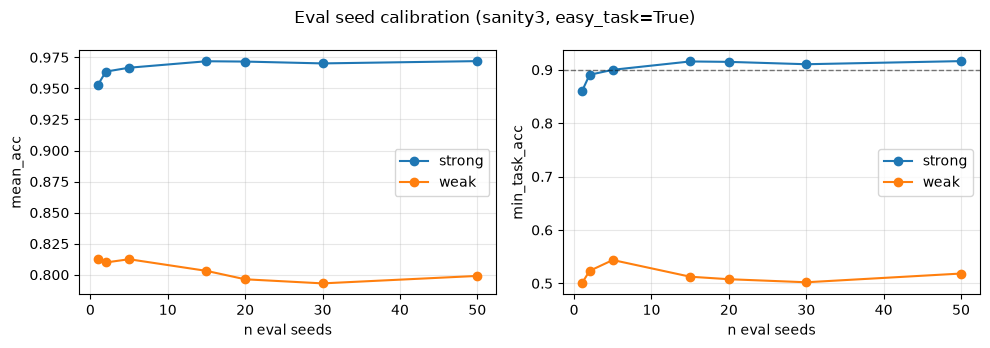

model      strong      weak
n_seeds                    
1        0.953125  0.812500
2        0.963542  0.809896
5        0.966667  0.812500
15       0.971875  0.803125
20       0.971615  0.796354
30       0.970139  0.793056
50       0.971979  0.799063


In [12]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import torch

from cmc.pareto import DEFAULT_EVAL_SEEDS
from cmc.train_cog import evaluate_pareto_metrics, load_checkpoint, resolve_active_tasks
from cmc.paths import CHECKPOINTS_DIR

CAL_TASKS = resolve_active_tasks("sanity3", None)
CAL_BATCH = 64
BASE_SEEDS = [10000 + i for i in range(50)]
N_LIST = [1, 2, 5, 15, 20, 30, 50]
FAIL_THRESH = 0.9
CHECKPOINTS = {
    "strong": CHECKPOINTS_DIR / "dale_20_50000_2026_09_05_02_50_56.pt",
    "weak": CHECKPOINTS_DIR / "dale_3_1000_2026_09_16_15_47_03.pt",
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rows = []
for label, ckpt in CHECKPOINTS.items():
    if not ckpt.is_file():
        print(f"Skip {label}: missing {ckpt}")
        continue
    model, config, _ = load_checkpoint(ckpt, device=device)
    for n in N_LIST:
        seeds = tuple(BASE_SEEDS[:n])
        m = evaluate_pareto_metrics(
            model,
            config,
            CAL_TASKS,
            device,
            eval_seeds=seeds,
            batch_size=CAL_BATCH,
            easy_task=True,
        )
        n_fail_tasks = sum(
            1 for k, v in m.items() if k.startswith("acc_") and v < FAIL_THRESH
        )
        rows.append(
            {
                "model": label,
                "n_seeds": n,
                "mean_acc": m["mean_acc"],
                "min_task_acc": m["min_task_acc"],
                "n_tasks_below_thresh": n_fail_tasks,
            }
        )

cal = pd.DataFrame(rows)
print(f"pareto.py DEFAULT_EVAL_SEEDS = {DEFAULT_EVAL_SEEDS}")
if cal.empty:
    print("No checkpoints found — update CHECKPOINTS paths and re-run.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    for label, sub in cal.groupby("model"):
        sub = sub.sort_values("n_seeds")
        axes[0].plot(sub["n_seeds"], sub["mean_acc"], "o-", label=label)
        axes[1].plot(sub["n_seeds"], sub["min_task_acc"], "o-", label=label)
    axes[0].set_xlabel("n eval seeds")
    axes[0].set_ylabel("mean_acc")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].set_xlabel("n eval seeds")
    axes[1].set_ylabel("min_task_acc")
    axes[1].axhline(FAIL_THRESH, color="k", ls="--", lw=1, alpha=0.5)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    fig.suptitle("Eval seed calibration (sanity3, easy_task=True)")
    fig.tight_layout()
    plt.show()
    print(cal.pivot(index="n_seeds", columns="model", values="mean_acc"))

In [13]:
# Print the number of chosen seeds for each model
for label, sub in cal.groupby("model"):
    chosen_n_seeds = sub[sub["n_tasks_below_thresh"] == 0]["n_seeds"]
    if not chosen_n_seeds.empty:
        print(f"Model '{label}' can use {chosen_n_seeds.max()} eval seeds without failing any tasks.")
    else:
        print(f"Model '{label}' fails at least one task for all tested eval seeds.")

Model 'strong' can use 50 eval seeds without failing any tasks.
Model 'weak' fails at least one task for all tested eval seeds.


In [14]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cmc.paths import PARETO_RUNS_DIR

# Point to a completed sweep output directory
RUN_DIR = PARETO_RUNS_DIR / "dale_core5_6x6_2026_09_23_05_45_12_5802320"

csv_path = RUN_DIR / "summary.csv"
json_path = RUN_DIR / "summary.json"

df = pd.read_csv(csv_path)
with json_path.open() as f:
    meta = json.load(f)

OBJECTIVE_LABELS = {
    "mean_acc": "mean task accuracy",
    "min_task_acc": "min task accuracy",
    "task_loss": "task loss",
    "metabolic_cost": "metabolic cost",
    "wiring_cost": "wiring cost",
}

OBJECTIVE_MAXIMIZE = {
    "mean_acc": True,
    "task_loss": False,
    "metabolic_cost": False,
    "wiring_cost": False,
}


def _default_task_objective(meta, df):
    if meta.get("pareto_task_objective") == "mean_acc":
        return "mean_acc"
    if meta.get("eval_seeds"):
        return "mean_acc"
    objs = meta.get("pareto_objectives") or []
    if objs and objs[0] in OBJECTIVE_LABELS:
        return objs[0]
    return "task_loss"


def infer_pareto_setup(meta, df):
    """Use summary.json metadata, or infer 1D sweep from unique lambdas."""
    if meta.get("sweep_mode") in ("rate", "connectivity", "both") and meta.get(
        "pareto_objectives"
    ):
        return meta["sweep_mode"], tuple(meta["pareto_objectives"])

    task_obj = _default_task_objective(meta, df)
    n_lr = df["lambda_rate"].nunique()
    n_lc = df["lambda_connectivity"].nunique()
    if n_lr == 1 and n_lc > 1:
        return "connectivity", (task_obj, "wiring_cost")
    if n_lc == 1 and n_lr > 1:
        return "rate", (task_obj, "metabolic_cost")
    return "both", (task_obj, "metabolic_cost", "wiring_cost")


sweep_mode, pareto_objectives = infer_pareto_setup(meta, df)

# --- which networks count, and what "good at the tasks" means ----------------
# EXCLUDE_INFEASIBLE: drop networks that fail a task before computing the front.
#   Otherwise networks at chance land on it, because they are the cheapest in the
#   grid and nothing can beat them on cost. Set False to reproduce the old front.
# TASK_OBJECTIVE: "min_task_acc" is only high if EVERY task is done; "mean_acc"
#   lets a network abandon one task and still score ~0.9.
# The front is recomputed here, so these apply to old runs as well; the
# is_pareto column saved in summary.csv is ignored.
from cmc.pareto import FEASIBLE_MIN_TASK_ACC as _DEFAULT_FEASIBLE, compute_front

EXCLUDE_INFEASIBLE = True
TASK_OBJECTIVE = "min_task_acc"
FEASIBLE_MIN_TASK_ACC = _DEFAULT_FEASIBLE   # worst-task accuracy to count (0.6)

pareto_objectives = (TASK_OBJECTIVE,) + tuple(pareto_objectives[1:])
uses_mean_acc = TASK_OBJECTIVE in ("mean_acc", "min_task_acc")
_front, _feasible = compute_front(
    df.to_dict("records"),
    pareto_objectives,
    exclude_infeasible=EXCLUDE_INFEASIBLE,
    min_task_acc=FEASIBLE_MIN_TASK_ACC,
)
df["is_pareto"] = _front
df["is_feasible"] = _feasible

print(
    f"Runs: {len(df)}  |  feasible (min_task_acc >= {FEASIBLE_MIN_TASK_ACC}): "
    f"{int(_feasible.sum())}  |  Pareto points: {int(_front.sum())}  "
    f"({'infeasible excluded' if EXCLUDE_INFEASIBLE else 'all networks compete'})"
)
print(f"Tasks: {meta['active_tasks']}")
print(f"Sweep mode: {sweep_mode}  |  Pareto objectives: {pareto_objectives}")
if meta.get("eval_seeds"):
    print(f"Eval seeds ({len(meta['eval_seeds'])}): {meta['eval_seeds'][:5]}...")
elif uses_mean_acc:
    print("Note: no eval_seeds in meta — legacy or hand-edited summary.")
elif pareto_objectives[0] == "task_loss":
    print("Note: legacy run (Pareto on task_loss). Re-run pareto.py for seeded mean_acc.")
if meta.get("fix_lambda_rate") is not None:
    print(f"Fixed lambda_rate = {meta['fix_lambda_rate']}")
if meta.get("fix_lambda_connectivity") is not None:
    print(f"Fixed lambda_connectivity = {meta['fix_lambda_connectivity']}")

# --- plotting helpers -------------------------------------------------------
# The lambda=0 anchor is an unconstrained network: nothing bounds its firing
# rates, so its metabolic cost sits ~60-100x above every constrained point and
# varies hugely across seeds. It is a real Pareto point, not a glitch, but on a
# linear axis it flattens the other 25 points onto zero. Mark it, and use log
# axes wherever a cost spans more than a decade.
COST_COLS = {"task_loss", "metabolic_cost", "wiring_cost", "conn_frac"}

is_anchor = (df["lambda_rate"] == 0) & (df["lambda_connectivity"] == 0)


def maybe_log(ax, col, which="x", frame=None):
    """Log-scale one axis if `col` is a positive cost spanning >1 decade."""
    if col not in COST_COLS:
        return
    v = (df if frame is None else frame)[col]
    v = v[v > 0]
    if len(v) and v.max() / v.min() > 10:
        (ax.set_xscale if which == "x" else ax.set_yscale)("log")


def dedupe_legend(ax, **kw):
    handles, labels = ax.get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    ax.legend(uniq.values(), uniq.keys(), **kw)


if is_anchor.any():
    a = df.loc[is_anchor].iloc[0]
    rest = df.loc[~is_anchor, "metabolic_cost"]
    print(
        f"\nlambda=0 anchor: mean_acc={a['mean_acc']:.4f}  "
        f"metabolic={a['metabolic_cost']:.4g} (+/-{a['metabolic_cost_std']:.2g})  "
        f"= {a['metabolic_cost'] / rest.max():.0f}x the largest constrained point"
    )

df.head()

Runs: 37  |  feasible (min_task_acc >= 0.6): 16  |  Pareto points: 14  (infeasible excluded)
Tasks: ['fdgo', 'fdanti', 'dm1', 'contextdm1', 'dmsgo']
Sweep mode: both  |  Pareto objectives: ('min_task_acc', 'metabolic_cost', 'wiring_cost')
Eval seeds (10): [10000, 10001, 10002, 10003, 10004]...

lambda=0 anchor: mean_acc=0.9676  metabolic=1.129 (+/-0.6)  = 14x the largest constrained point


,lambda_rate,lambda_connectivity,n_seeds,mean_acc,mean_acc_std,min_task_acc,min_task_acc_std,task_loss,task_loss_std,metabolic_cost,...,acc_dmsgo,acc_dmsgo_std,acc_fdanti,acc_fdanti_std,acc_fdgo,acc_fdgo_std,train_time_s,is_pareto,run_idx,is_feasible
0,0.00,0.000000,3,0.967604,0.005081,0.847917,0.014851,0.003621,0.000583,1.129500,...,0.847917,0.014851,1.0,0.0,1.0,0.0,1289.207844,False,1,True
1,0.02,1.000000,3,0.969896,0.000786,0.849479,0.003932,0.003283,0.000282,0.047070,...,0.849479,0.003932,1.0,0.0,1.0,0.0,1316.492531,False,2,True
2,0.02,2.091279,3,0.964688,0.004507,0.824479,0.023193,0.003592,0.000486,0.050284,...,0.824479,0.023193,1.0,0.0,1.0,0.0,1312.145402,True,3,True
3,0.02,4.373448,3,0.952813,0.018318,0.765104,0.092139,0.004183,0.000500,0.055815,...,0.765104,0.092139,1.0,0.0,1.0,0.0,1313.771329,True,4,True
4,0.02,9.146101,3,0.935312,0.019978,0.676563,0.099890,0.004991,0.000624,0.064794,...,0.676563,0.099890,1.0,0.0,1.0,0.0,1312.943840,True,5,True


In [15]:
import plotly.graph_objects as go
import numpy as np

# Toggle: plot metabolic/wiring cost axes in log10 space instead of linear.
USE_LOG_COSTS = True

if USE_LOG_COSTS:
    df["log_metabolic_cost"] = np.log10(df["metabolic_cost"].clip(lower=1e-12))
    df["log_wiring_cost"] = np.log10(df["wiring_cost"].clip(lower=1e-12))
    OBJECTIVE_LABELS["log_metabolic_cost"] = "log10(metabolic cost)"
    OBJECTIVE_LABELS["log_wiring_cost"] = "log10(wiring cost)"
    pareto_objectives = tuple(
        "log_metabolic_cost" if o == "metabolic_cost"
        else "log_wiring_cost" if o == "wiring_cost"
        else o
        for o in pareto_objectives
    )

pareto = df["is_pareto"].astype(bool)

def hover_text(sub):
    return [
        f"λ_rate={r.lambda_rate:.4g}<br>"
        f"λ_conn={r.lambda_connectivity:.4g}<br>"
        f"acc={r.mean_acc:.3f}  min={getattr(r, 'min_task_acc', float('nan')):.3f}<br>"
        f"task={r.task_loss:.4f}<br>"
        f"meta={r.metabolic_cost:.4f}<br>"
        f"wire={r.wiring_cost:.4f}"
        for r in sub.itertuples()
    ]

grid = df.loc[~pareto]
front = df.loc[pareto]
battery = meta.get("task_battery", "")

if len(pareto_objectives) == 2:
    xcol, ycol = pareto_objectives
    if sweep_mode == "connectivity":
        sweep_label = (
            f"λ_rate fixed ({df['lambda_rate'].iloc[0]:.4g}), sweep λ_conn"
        )
    else:
        sweep_label = (
            f"λ_conn fixed ({df['lambda_connectivity'].iloc[0]:.4g}), sweep λ_rate"
        )
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=grid[xcol],
            y=grid[ycol],
            mode="markers",
            name="grid",
            marker=dict(size=8, color="lightgray", opacity=0.85),
            text=hover_text(grid),
            hoverinfo="text",
        )
    )
    fig.add_trace(
        go.Scatter(
            x=front[xcol],
            y=front[ycol],
            mode="markers+text",
            name="Pareto",
            marker=dict(size=11, color="orange"),
            text=[
                f"λr={r.lambda_rate:.3g}, λc={r.lambda_connectivity:.3g}"
                for r in front.itertuples()
            ],
            textposition="top center",
            textfont=dict(size=9),
            hovertext=hover_text(front),
            hoverinfo="text",
        )
    )
    fig.update_layout(
        title=f"Pareto front (2D) — {battery}  |  {sweep_label}",
        xaxis_title=OBJECTIVE_LABELS[xcol],
        yaxis_title=OBJECTIVE_LABELS[ycol],
        width=800,
        height=600,
        legend=dict(x=0.02, y=0.98),
    )
else:
    x3, y3, z3 = pareto_objectives
    fig = go.Figure()
    fig.add_trace(
        go.Scatter3d(
            x=grid[x3],
            y=grid[y3],
            z=grid[z3],
            mode="markers",
            name="grid",
            marker=dict(size=5, color="lightgray", opacity=0.85),
            text=hover_text(grid),
            hoverinfo="text",
        )
    )
    fig.add_trace(
        go.Scatter3d(
            x=front[x3],
            y=front[y3],
            z=front[z3],
            mode="markers+text",
            name="Pareto",
            marker=dict(size=8, color="orange"),
            text=[f"({r.lambda_rate:.3g}, {r.lambda_connectivity:.3g})" for r in front.itertuples()],
            textposition="top center",
            textfont=dict(size=10),
            hovertext=hover_text(front),
            hoverinfo="text",
        )
    )
    fig.update_layout(
        title=f"Pareto front (3D) — {battery} ({len(df)} runs)",
        scene=dict(
            xaxis_title=OBJECTIVE_LABELS[x3],
            yaxis_title=OBJECTIVE_LABELS[y3],
            zaxis_title=OBJECTIVE_LABELS[z3],
            aspectmode="cube",
        ),
        width=900,
        height=700,
        legend=dict(x=0.02, y=0.98),
    )

fig.show()

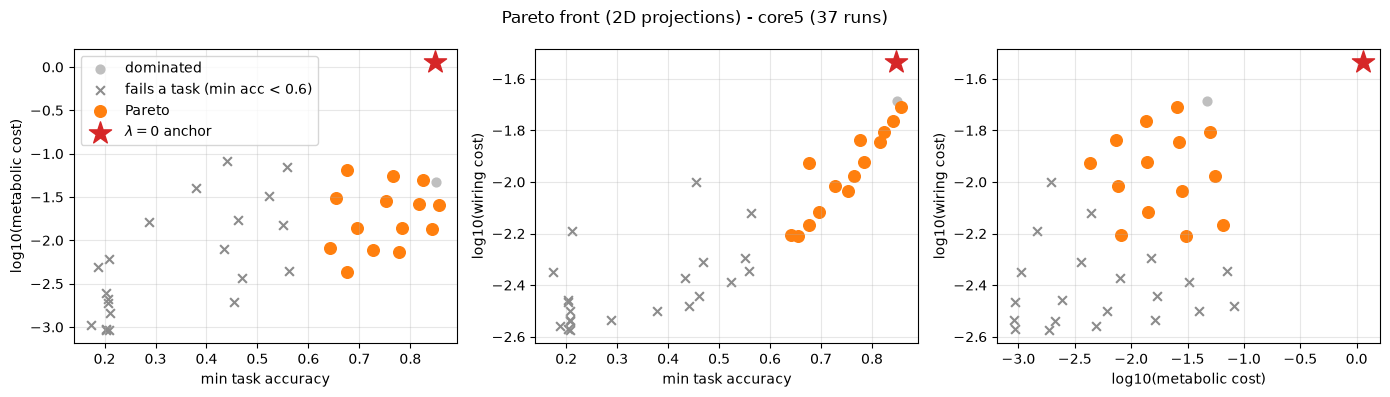

In [16]:
# Matplotlib: 2D Pareto plane for 1D sweeps, else 1x3 projection panels.
# Cost axes are log-scaled when they span >1 decade, and the lambda=0 anchor is
# marked separately -- otherwise it dominates the axis and hides the front.
pareto = df["is_pareto"].astype(bool)
battery = meta.get("task_battery", "")


feasible = df["is_feasible"].astype(bool)


def pareto_panel(ax, xc, yc):
    grid = ~pareto & ~is_anchor & feasible
    front = pareto & ~is_anchor
    dead = ~feasible & ~is_anchor
    ax.scatter(df.loc[grid, xc], df.loc[grid, yc], c="0.75", s=40, label="dominated")
    ax.scatter(
        df.loc[dead, xc], df.loc[dead, yc], marker="x", c="0.55", s=40,
        label=f"fails a task (min acc < {FEASIBLE_MIN_TASK_ACC})",
    )
    ax.scatter(df.loc[front, xc], df.loc[front, yc], c="C1", s=70, label="Pareto")
    if is_anchor.any():
        ax.scatter(
            df.loc[is_anchor, xc],
            df.loc[is_anchor, yc],
            marker="*",
            s=280,
            c="C3",
            zorder=5,
            label=r"$\lambda=0$ anchor",
        )
    ax.set_xlabel(OBJECTIVE_LABELS[xc])
    ax.set_ylabel(OBJECTIVE_LABELS[yc])
    ax.grid(True, alpha=0.3)
    maybe_log(ax, xc, "x")
    maybe_log(ax, yc, "y")


if len(pareto_objectives) == 2:
    xc, yc = pareto_objectives
    fig, ax = plt.subplots(figsize=(6, 5))
    pareto_panel(ax, xc, yc)
    ax.legend(loc="best")
    fig.suptitle(f"Pareto front (2D) - {battery}  |  sweep={sweep_mode}")
else:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    if len(pareto_objectives) == 3:
        a, b, c = pareto_objectives
        pairs = [(a, b), (a, c), (b, c)]
    else:
        pairs = [
            ("task_loss", "metabolic_cost"),
            ("task_loss", "wiring_cost"),
            ("metabolic_cost", "wiring_cost"),
        ]
    for ax, (xc, yc) in zip(axes, pairs):
        pareto_panel(ax, xc, yc)
    axes[0].legend(loc="best")
    fig.suptitle(f"Pareto front (2D projections) - {battery} ({len(df)} runs)")

fig.tight_layout()
plt.show()

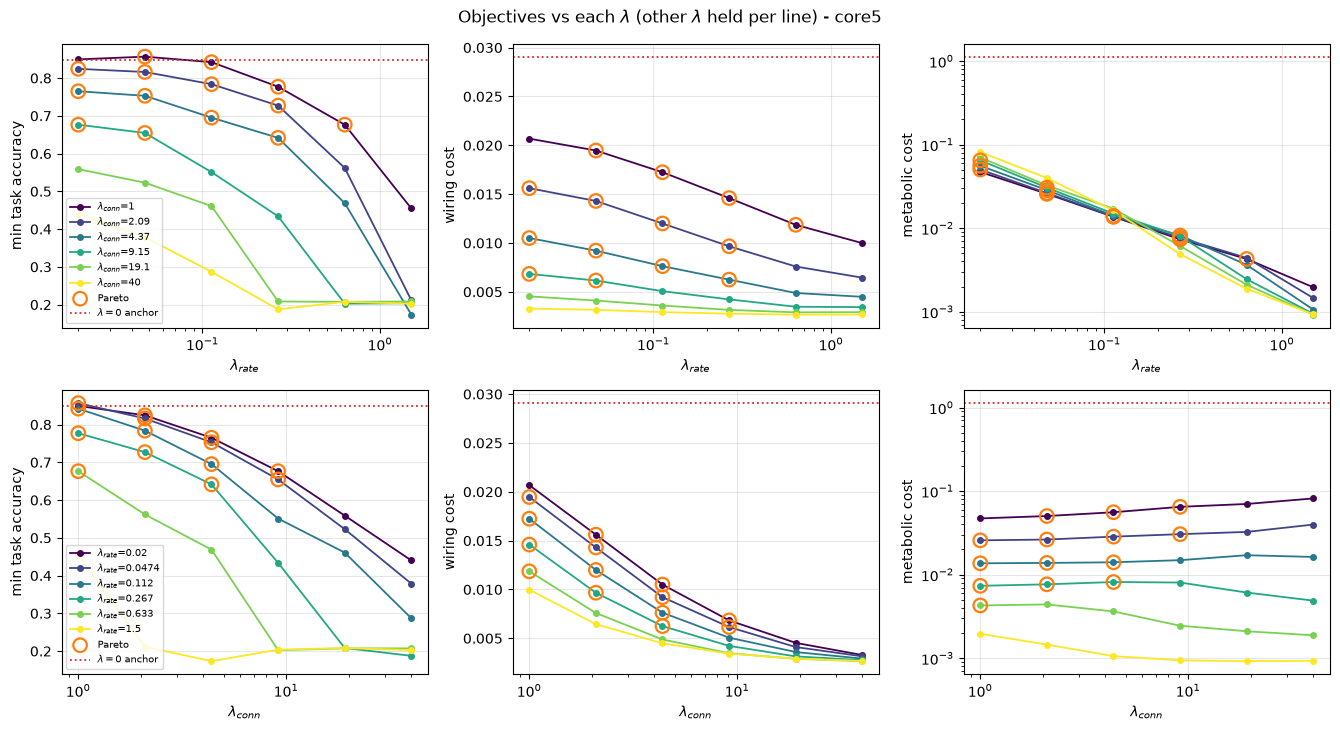

In [17]:
# Objectives vs the swept lambda(s).
#
# For a "both" sweep two lambdas vary at once, so plotting everything against
# lambda_rate alone stacks n_lc points at each x and shows no trend. Instead
# draw both marginals: one row per swept lambda, one line per value of the
# other. The lambda=0 anchor belongs to neither family (it has no partner value
# and cannot sit on a log axis), so it is drawn as a reference line.
pareto = df["is_pareto"].astype(bool)
battery = meta.get("task_battery", "")
objective_cols = [TASK_OBJECTIVE, "wiring_cost", "metabolic_cost"]
grid_df = df.loc[~is_anchor]


def anchor_ref(ax, col):
    if is_anchor.any():
        ax.axhline(
            df.loc[is_anchor, col].iloc[0],
            color="C3",
            ls=":",
            lw=1.3,
            label=r"$\lambda=0$ anchor",
        )


if sweep_mode in ("connectivity", "rate"):
    lam_col = "lambda_connectivity" if sweep_mode == "connectivity" else "lambda_rate"
    lam_label = r"$\lambda_{conn}$" if sweep_mode == "connectivity" else r"$\lambda_{rate}$"
    plot_df = grid_df.sort_values(lam_col)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True)
    for ax, col in zip(axes, objective_cols):
        ax.plot(
            plot_df[lam_col], plot_df[col], "o-",
            color="0.55", markersize=5, linewidth=1.2, label="all runs",
        )
        p = plot_df.loc[plot_df["is_pareto"].astype(bool)]
        ax.scatter(p[lam_col], p[col], c="C1", s=70, zorder=3, label="Pareto")
        anchor_ref(ax, col)
        if (plot_df[lam_col] > 0).all():
            ax.set_xscale("log")
        ax.set_ylabel(OBJECTIVE_LABELS[col])
        ax.grid(True, alpha=0.3)
        maybe_log(ax, col, "y", frame=grid_df)

    dedupe_legend(axes[0], loc="best", fontsize=8)
    fig.supxlabel(lam_label)

    # Read the held-fixed lambda from metadata: df.iloc[0] is the lambda=0
    # anchor row, not the fixed value, whenever the anchor is included.
    fixed_key = "fix_lambda_rate" if sweep_mode == "connectivity" else "fix_lambda_connectivity"
    other_col = "lambda_rate" if sweep_mode == "connectivity" else "lambda_connectivity"
    fixed_val = meta.get(fixed_key)
    if fixed_val is None:
        uniq = grid_df[other_col].unique()
        fixed_val = uniq[0] if len(uniq) == 1 else float("nan")
    fixed_name = r"$\lambda_{rate}$" if sweep_mode == "connectivity" else r"$\lambda_{conn}$"
    fig.suptitle(rf"Objectives vs swept $\lambda$ - {battery}  ({fixed_name} = {fixed_val:.4g})")
else:
    marginals = [
        ("lambda_rate", "lambda_connectivity", r"$\lambda_{rate}$", r"\lambda_{conn}"),
        ("lambda_connectivity", "lambda_rate", r"$\lambda_{conn}$", r"\lambda_{rate}"),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.4), sharey="col")
    cmap = plt.get_cmap("viridis")

    for axrow, (xcol, huecol, xlab, huelab) in zip(axes, marginals):
        hues = sorted(grid_df[huecol].unique())
        colors = {h: cmap(i / max(len(hues) - 1, 1)) for i, h in enumerate(hues)}
        for ax, col in zip(axrow, objective_cols):
            for h in hues:
                g = grid_df[grid_df[huecol] == h].sort_values(xcol)
                ax.plot(
                    g[xcol], g[col], "o-", markersize=4, linewidth=1.3,
                    color=colors[h], label=f"${huelab}$={h:.3g}",
                )
            p = grid_df.loc[grid_df["is_pareto"].astype(bool)]
            ax.scatter(
                p[xcol], p[col], facecolors="none", edgecolors="C1",
                s=95, linewidths=1.6, zorder=4, label="Pareto",
            )
            anchor_ref(ax, col)
            if (grid_df[xcol] > 0).all():
                ax.set_xscale("log")
            ax.set_xlabel(xlab)
            ax.set_ylabel(OBJECTIVE_LABELS[col])
            ax.grid(True, alpha=0.3)
            maybe_log(ax, col, "y", frame=grid_df)
        dedupe_legend(axrow[0], fontsize=7, loc="best")

    fig.suptitle(
        rf"Objectives vs each $\lambda$ (other $\lambda$ held per line) - {battery}"
    )

fig.tight_layout()
plt.show()

In [18]:
cols = [
    "lambda_rate",
    "lambda_connectivity",
    "mean_acc",
    "min_task_acc",
    "task_loss",
    "metabolic_cost",
    "wiring_cost",
    "is_feasible",
    "is_pareto",
]
cols = [c for c in cols if c in df.columns]
sort_cols = [TASK_OBJECTIVE, "metabolic_cost", "wiring_cost"]
df.sort_values(sort_cols, ascending=[False, True, True] if uses_mean_acc else True)[cols]

,lambda_rate,lambda_connectivity,mean_acc,min_task_acc,task_loss,metabolic_cost,wiring_cost,is_feasible,is_pareto
7,0.047429,1.000000,0.971354,0.856771,0.003221,0.025719,0.019467,True,True
1,0.020000,1.000000,0.969896,0.849479,0.003283,0.047070,0.020682,True,False
0,0.000000,0.000000,0.967604,0.847917,0.003621,1.129500,0.029076,True,False
13,0.112475,1.000000,0.968333,0.842187,0.003371,0.013669,0.017244,True,True
2,0.020000,2.091279,0.964688,0.824479,0.003592,0.050284,0.015610,True,True
8,0.047429,2.091279,0.963125,0.816146,0.003730,0.026309,0.014302,True,True
14,0.112475,2.091279,0.956562,0.783854,0.004114,0.013804,0.011998,True,True
19,0.266727,1.000000,0.955208,0.777083,0.004066,0.007349,0.014598,True,True
3,0.020000,4.373448,0.952813,0.765104,0.004183,0.055815,0.010503,True,True
9,0.047429,4.373448,0.950625,0.753125,0.004682,0.028487,0.009215,True,True
